In [1]:
import torch
import torch.nn as nn
import lightning.pytorch as pl
from lightning.pytorch import loggers as pl_loggers

import numpy as np

In [2]:
class BaseLineNetworkDirect(pl.LightningModule):

    def __init__(self):
        super(BaseLineNetworkDirect, self).__init__()

        self.lr = 1e-3
        self.example_input_array = torch.rand(1, 5, 128, 64)

        self.network = nn.Sequential(
            nn.Conv2d(in_channels=5, out_channels=64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv2d(in_channels=64, out_channels=64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv2d(in_channels=64, out_channels=64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv2d(in_channels=64, out_channels=64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv2d(in_channels=64, out_channels=5, kernel_size=3, padding=1),
        )
    
    def forward(self, x):
        return self.network(x)
    
    def training_step(self, batch, batch_idx):
        x, y = batch

        y_hat = self(x)

        loss = nn.functional.mse_loss(y_hat, y)

        self.log('train_loss', loss, on_epoch=True)

        return loss
    
    def validation_step(self, batch, batch_idx):
        x, y = batch

        y_hat = self(x)

        loss = nn.functional.mse_loss(y_hat, y)

        self.log('val_loss', loss, on_epoch=True)
    
    def configure_optimizers(self):
        optimizer = torch.optim.Adam(self.parameters(), lr=self.lr)

        return {
            'optimizer': optimizer
        }

In [3]:
class BaseLineDatasetDirect(torch.utils.data.Dataset):

    def __init__(self, path: str, forecast_steps: int = 1):
        super(BaseLineDatasetDirect, self).__init__()

        self.path = path
        self.forecast_steps = forecast_steps

        self.mean: np.ndarray = np.array([5.4008180e+04, 2.7393976e+02, 2.3674958e-03, 2.7760931e+02, 6.2221546e+00], dtype=np.float32)
        self.std: np.ndarray = np.array([3.3518201e+03, 1.5841744e+01, 2.4138752e-03, 2.1723423e+01, 3.4207888e+00], dtype=np.float32)
        
        self.data = self._load_data()

    def _load_data(self) -> np.ndarray:
        path = self.path
        c = 5
        w, h = 128, 64

        data = np.memmap(path, mode="r", dtype=np.float32).reshape(-1, c, w, h)

        return data
    
    def denormalize_sample(self, sample: np.ndarray) -> np.ndarray:
        return sample * self.std[:, None, None] + self.mean[:, None, None]

    def __len__(self):
        return len(self.data) - self.forecast_steps

    def __getitem__(self, idx):

        item_1 = self.data[idx]
        # 1 = 6h, 2 = 12h, 3 = 18h, 4 = 24h, 5 = 30h, 6 = 36h, 7 = 42h, 8 = 48h, 9 = 54h, 10 = 60h, 11 = 66h, 12 = 72h
        item_2 = self.data[idx + self.forecast_steps]

        # normalize
        item_1 = (item_1 - self.mean[:, None, None]) / self.std[:, None, None]
        item_2 = (item_2 - self.mean[:, None, None]) / self.std[:, None, None]

        return item_1, item_2

In [ ]:
def train(num_epochs: int = 100, batch_size: int = 256, forecast_steps: int = 12):

    model = BaseLineNetworkDirect()
    train_ds = BaseLineDatasetDirect(path="train.memmap", forecast_steps=forecast_steps)
    val_ds = BaseLineDatasetDirect(path="val.memmap", forecast_steps=forecast_steps)

    train_dataloader = torch.utils.data.DataLoader(
        train_ds,
        batch_size=batch_size,
        shuffle=True,
    )

    val_dataloader = torch.utils.data.DataLoader(
        val_ds,
        batch_size=batch_size,
        shuffle=False,
    )

    tb_logger = pl_loggers.TensorBoardLogger(
        save_dir="logs/", name=f"baseline_{forecast_steps * 6}h")

    trainer = pl.Trainer(
        logger=tb_logger,
        max_epochs=num_epochs,
    )

    trainer.fit(
        model=model,
        train_dataloaders=train_dataloader,
        val_dataloaders=val_dataloader
    )

    trainer.save_checkpoint(f"baseline_direct_{forecast_steps * 6}.ckpt")

train(num_epochs=100, batch_size=256, forecast_steps=4)
train(num_epochs=100, batch_size=256, forecast_steps=8)
train(num_epochs=100, batch_size=256, forecast_steps=12)

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs

  | Name    | Type       | Params | Mode  | In sizes        | Out sizes      
-----------------------------------------------------------------------------------
0 | network | Sequential | 116 K  | train | [1, 5, 128, 64] | [1, 5, 128, 64]
-----------------------------------------------------------------------------------
116 K     Trainable params
0         Non-trainable params
116 K     Total params
0.466     Total estimated model params size (MB)
10        Modules in train mode
0         Modules in eval mode


Sanity Checking DataLoader 0:   0%|          | 0/1 [00:00<?, ?it/s]

c:\Users\hendr\miniconda3\envs\LUN\Lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:424: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=7` in the `DataLoader` to improve performance.

Detected KeyboardInterrupt, attempting graceful shutdown ...


NameError: name 'exit' is not defined

In [ ]:
model = BaseLineNetworkDirect.load_from_checkpoint("weights/baseline.ckpt").to("cpu")
model.eval()
model.freeze()

dataset = BaseLineDatasetDirect(path="train.memmap")

print(dataset.data.shape)

(968, 5, 128, 64)


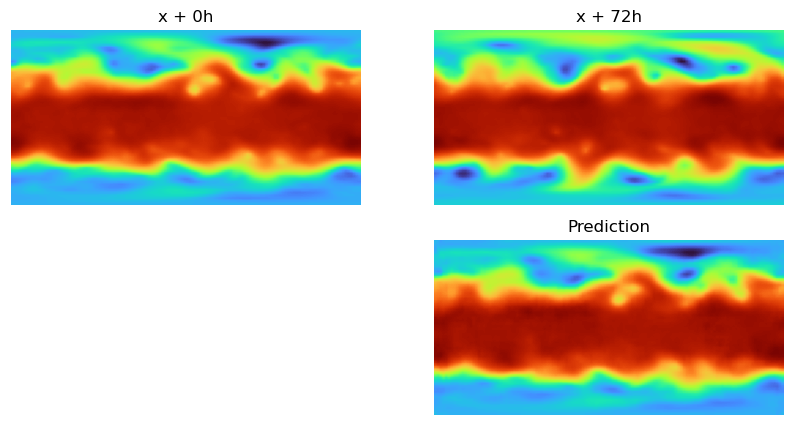

57841.785 47519.965
57838.57 47405.496
1169.9375


In [38]:
x, _ = dataset[0]
y, _ = dataset[12]

pred = model(torch.Tensor(x).unsqueeze(0))
pred = pred.detach().squeeze(0).numpy()

from matplotlib import pyplot as plt

feature = 0

fig, axs = plt.subplots(2, 2, figsize=(10, 5))

axs[0, 0].imshow(x[feature].T, origin="lower", cmap="turbo")
axs[0, 0].set_title("x + 0h")
axs[0, 0].axis("off")

axs[0, 1].imshow(y[feature].T, origin="lower", cmap="turbo")
axs[0, 1].set_title("x + 72h")
axs[0, 1].axis("off")

axs[1, 0].axis("off")

axs[1, 1].imshow(pred[feature].T, origin="lower", cmap="turbo")
axs[1, 1].set_title("Prediction")
axs[1, 1].axis("off")

plt.show()

denorm_y = dataset.denormalize_sample(y)
denorm_pred = dataset.denormalize_sample(pred)

print(denorm_y[feature].max(), denorm_y[feature].min())
print(denorm_pred[feature].max(), denorm_pred[feature].min())

rmse = np.sqrt(np.mean((denorm_y[feature] - denorm_pred[feature]) ** 2))
print(rmse)